<a href="https://colab.research.google.com/github/danielarugeles1972-prog/ESTADISTICA-II/blob/main/tarea_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA 2:  MODELOS DE REGRESIÓN MÚLTIPLE

**Integrantes**


*   Paula Alexandra Camacho Cuadros *- 2232742*  
*   Daniela Rugeles Rueda *-2231940*
*   Daniela Salon Quintero *-2231927*



La base de datos SB11_20231.TXT recoge los resultados de la prueba Saber 11°, aplicada por el* (Instituto Colombiano para la Evaluación de la Educación)* en el primer corte del año 2023. Esta prueba evalúa a los estudiantes de último grado de educación media en Colombia en cinco áreas principales: Lectura Crítica, Matemáticas, Ciencias Naturales, Sociales y Ciudadanas, e Inglés.

Además, dentro de la base se encuentra la variable ESTU_INSE_INDIVIDUAL, que corresponde al Índice de Nivel Socioeconómico de cada estudiante. Este indicador es construido por el ICFES a partir de la información del cuestionario socioeconómico, donde se tienen en cuenta aspectos como la educación de los padres, los ingresos del hogar y algunos bienes disponibles en la vivienda.

A partir de esta información, en este trabajo se busca utilizar modelos de regresión, como la regresión lineal múltiple y una red neuronal tipo MLP, con el objetivo de estimar el nivel socioeconómico de los estudiantes a partir de sus puntajes en las cinco áreas evaluadas

In [ ]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()
import pandas as pd
import io
datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),
 delimiter='¬')

Saving SB11_20231.TXT to SB11_20231.TXT


/tmp/ipykernel_8947/4288272213.py:5: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),


Se carga la base de datos SB11_20231.TXT

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neural_network import MLPRegressor
from scipy.stats import spearmanr, kendalltau

In [ ]:
icfes_sin_nan = datos_icfes[(~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
                             (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
                             (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
                             (~datos_icfes['PUNT_C_NATURALES'].isna()) &
                             (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
                             (~datos_icfes['PUNT_INGLES'].isna())]

In [ ]:
bytes = io.BytesIO(uploaded['SB11_20231.TXT'])
tabla_icfes_sin_nan = pd.read_csv(bytes, sep='¬', index_col=0)
tabla_icfes_sin_nan.head(4)

/tmp/ipykernel_8947/2261817667.py:2: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  tabla_icfes_sin_nan = pd.read_csv(bytes, sep='¬', index_col=0)


,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,ESTU_MCPIO_RESIDE,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
ESTU_TIPODOCUMENTO,,,,,,,,,,,,,,,,,,,,,
TI,COLOMBIA,F,04/11/2005,20231,SB11202310019049,ESTUDIANTE,COLOMBIA,CUNDINAMARCA,25,CHÍA,...,87.0,94.0,B+,422,100.0,67.532814,4.0,4,100.0,PUBLICAR
TI,COLOMBIA,M,08/04/2007,20231,SB11202310017318,ESTUDIANTE,COLOMBIA,VALLE,76,CALI,...,NaN,NaN,NaN,326,NaN,47.223972,2.0,3,100.0,PUBLICAR
TI,COLOMBIA,F,26/05/2006,20231,SB11202310030916,ESTUDIANTE,COLOMBIA,VALLE,76,YOTOCO,...,NaN,NaN,NaN,186,NaN,67.695519,4.0,3,40.0,PUBLICAR
CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,CALI,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR


In [ ]:
icfes_sin_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11853 entries, 0 to 12703
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ESTU_TIPODOCUMENTO             11853 non-null  object 
 1   ESTU_NACIONALIDAD              11853 non-null  object 
 2   ESTU_GENERO                    11853 non-null  object 
 3   ESTU_FECHANACIMIENTO           11853 non-null  object 
 4   PERIODO                        11853 non-null  int64  
 5   ESTU_CONSECUTIVO               11853 non-null  object 
 6   ESTU_ESTUDIANTE                11853 non-null  object 
 7   ESTU_PAIS_RESIDE               11853 non-null  object 
 8   ESTU_DEPTO_RESIDE              11853 non-null  object 
 9   ESTU_COD_RESIDE_DEPTO          11853 non-null  int64  
 10  ESTU_MCPIO_RESIDE              11853 non-null  object 
 11  ESTU_COD_RESIDE_MCPIO          11853 non-null  int64  
 12  ESTU_PRESENTACIONSABADO        11851 non-null  obje

In [ ]:
icfes_sin_nan.columns

Index(['ESTU_TIPODOCUMENTO', 'ESTU_NACIONALIDAD', 'ESTU_GENERO',
       'ESTU_FECHANACIMIENTO', 'PERIODO', 'ESTU_CONSECUTIVO',
       'ESTU_ESTUDIANTE', 'ESTU_PAIS_RESIDE', 'ESTU_DEPTO_RESIDE',
       'ESTU_COD_RESIDE_DEPTO', 'ESTU_MCPIO_RESIDE', 'ESTU_COD_RESIDE_MCPIO',
       'ESTU_PRESENTACIONSABADO', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE',
       'FAMI_TRABAJOLABORPADRE', 'FAMI_TRABAJOLABORMADRE',
       'FAMI_TIENEINTERNET', 'FAMI_TIENESERVICIOTV', 'FAMI_TIENECOMPUTADOR',
       'FAMI_TIENELAVADORA', 'FAMI_TIENEHORNOMICROOGAS', 'FAMI_TIENEAUTOMOVIL',
       'FAMI_TIENEMOTOCICLETA', 'FAMI_TIENECONSOLAVIDEOJUEGOS',
       'FAMI_NUMLIBROS', 'FAMI_COMELECHEDERIVADOS',
       'FAMI_COMECARNEPESCADOHUEVO', 'FAMI_COMECEREALFRUTOSLEGUMBRE',
       'FAMI_SITUACIONECONOMICA', 'ESTU_DEDICACIONLECTURADIARIA',
       'ESTU_DEDICACIONINTERNET', 'ESTU_HORASSEMANATRABAJA',
       'ESTU_TIPOREMUNERACION', 'COLE_CODIGO_

Los anteriores datos consisten en la información sobre las variables que nos arrojo el archivo SB11_20231.TXT


In [ ]:
tabla_ESTU_INSE_INDIVIDUAL = icfes_sin_nan
tabla_regresion = tabla_ESTU_INSE_INDIVIDUAL[["PUNT_LECTURA_CRITICA", "PUNT_MATEMATICAS", "PUNT_C_NATURALES", "PUNT_SOCIALES_CIUDADANAS", "PUNT_INGLES", "ESTU_INSE_INDIVIDUAL"]]
tabla_regresion.head(4)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
3,45,41,41,27,58.0,41.863163
4,53,55,41,56,69.0,51.223795
5,63,38,60,59,45.0,57.690401


Tomamos la variable respuesta 'ESTU_INSE_INDIVIDUAL' y con todas las variables explicativas 'PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS' y 'PUNT_INGLES'

<Axes: >

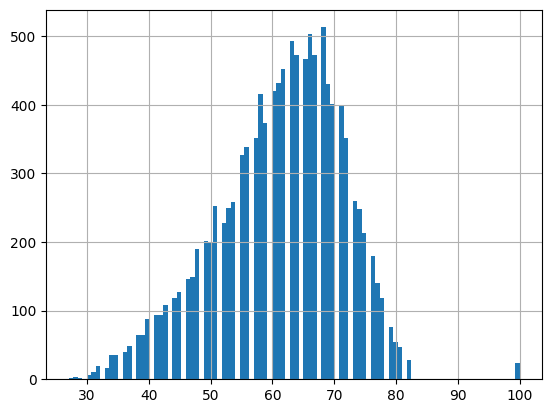

In [ ]:
tabla_regresion["PUNT_C_NATURALES"].hist(bins=100)

<Axes: >

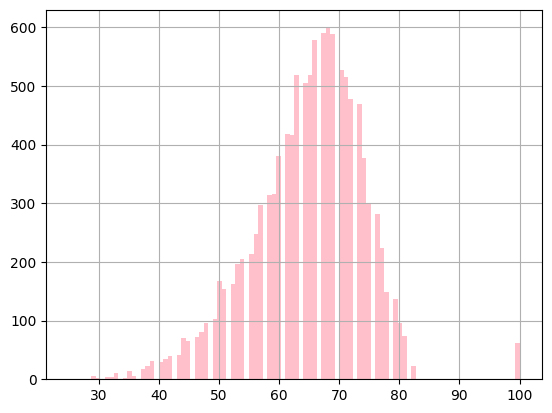

In [ ]:
tabla_regresion["PUNT_LECTURA_CRITICA"].hist(bins=100, color = 'pink')

<Axes: >

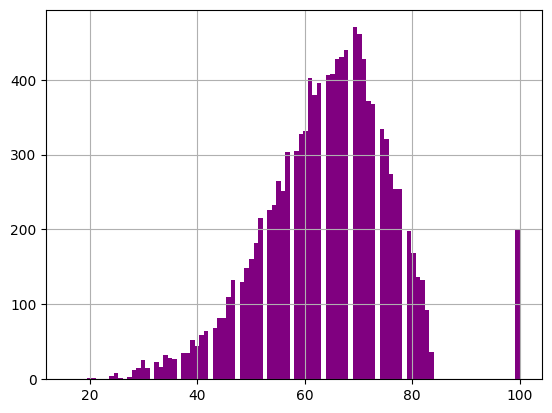

In [ ]:
tabla_regresion["PUNT_MATEMATICAS"].hist(bins=100, color = 'purple')

<Axes: >

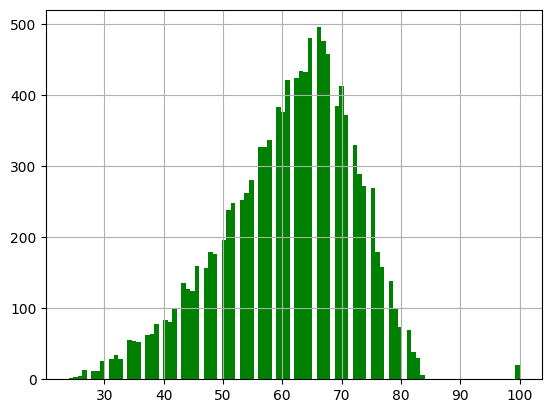

In [ ]:
tabla_regresion["PUNT_SOCIALES_CIUDADANAS"].hist(bins=100, color = 'green')

<Axes: >

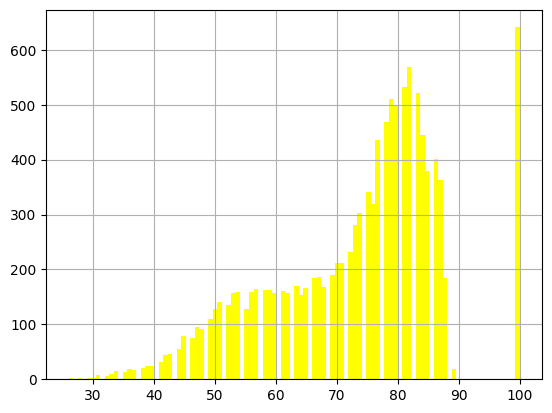

In [ ]:
tabla_regresion["PUNT_INGLES"].hist(bins=100, color ='yellow')

<Axes: >

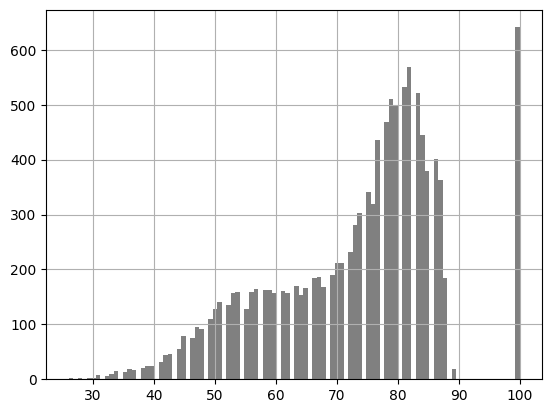

In [ ]:
PUNT_INGLES = tabla_regresion[(tabla_regresion["PUNT_INGLES"] <= 100)]
tabla_regresion["PUNT_INGLES"].hist(bins=100, color = 'gray')

Las gráficas anteriores representan histogramas de las variables analizadas, donde se aprecia una mayor concentración de los datos en rangos intermedios, así como la ausencia de valores atípicos relevantes.

In [ ]:
tabla_regresion1 = tabla_regresion[
    (tabla_regresion['PUNT_LECTURA_CRITICA'] <= 100) &
    (tabla_regresion['PUNT_MATEMATICAS'] <= 100) &
    (tabla_regresion['PUNT_C_NATURALES'] <= 100) &
    (tabla_regresion['PUNT_SOCIALES_CIUDADANAS'] <= 100) &
    (tabla_regresion['PUNT_INGLES'] <= 100) &
    (tabla_regresion['ESTU_INSE_INDIVIDUAL'] >= 0)
]

tabla_regresion1.head(4)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,83,77,77,87.0,67.532814
3,45,41,41,27,58.0,41.863163
4,53,55,41,56,69.0,51.223795
5,63,38,60,59,45.0,57.690401


En esta tabla se toman se realizo para determinar los valores que no son representativos y eliminarlos.


In [ ]:
x = np.array(tabla_regresion1["PUNT_LECTURA_CRITICA"]).reshape(-1,1)
y = tabla_regresion1["PUNT_MATEMATICAS"]
trainx, testx, trainy, testy = train_test_split(x, y, test_size=0.2, random_state=0)
modelo_lineal0 = LinearRegression()
regresion0 = modelo_lineal0.fit(trainx, trainy)
pred_lineal = regresion0.predict(testx)

In [ ]:
x0 = np.array(tabla_regresion1["PUNT_LECTURA_CRITICA"]).reshape(-1,1)
y0 = tabla_regresion1["PUNT_MATEMATICAS"]
modelo_lineal01 = LinearRegression()
regresion01 = modelo_lineal01.fit(x0, y0)
pred_lineal01 = regresion01.predict(x0)



# Diagramas de dispersión

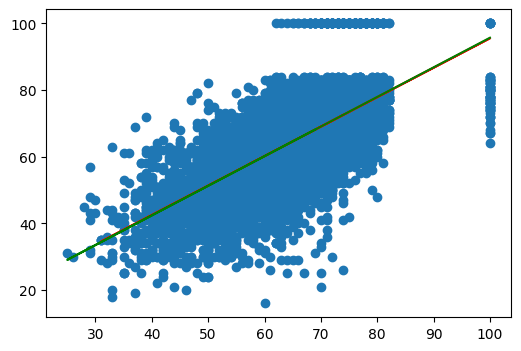

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(tabla_regresion["PUNT_LECTURA_CRITICA"], tabla_regresion["PUNT_MATEMATICAS"])
plt.plot(testx, pred_lineal, linestyle = '-', color ="red")
plt.plot(tabla_regresion1['PUNT_LECTURA_CRITICA'], pred_lineal01, linestyle='-', color ="green")
plt.show()

In [ ]:
x1 = np.array(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"]).reshape(-1,1)
y2 = tabla_regresion1["PUNT_MATEMATICAS"]
trainx2, testx2, trainy2, testy2 = train_test_split(x1, y2, test_size=0.2, random_state=0)
modelo_lineal02 = LinearRegression()
regresion02 = modelo_lineal02.fit(trainx2, trainy2)
pred_lineal = regresion02.predict(testx2)


In [ ]:
x02 = np.array(tabla_regresion1["PUNT_LECTURA_CRITICA"]).reshape(-1,1)
y02 = tabla_regresion1["PUNT_MATEMATICAS"]
modelo_lineal02 = LinearRegression()
regresion02 = modelo_lineal02.fit(x02, y02)
pred_lineal02 = regresion02.predict(x02)

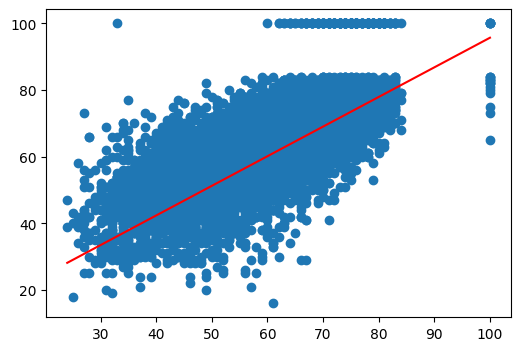

In [ ]:
import numpy as np
x_sociales_sorted = np.sort(tabla_regresion1['PUNT_SOCIALES_CIUDADANAS'].values).reshape(-1, 1)
pred_sociales_smooth = regresion02.predict(x_sociales_sorted)
plt.figure(figsize=(6,4))
plt.scatter(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["PUNT_MATEMATICAS"])
plt.plot(x_sociales_sorted, pred_sociales_smooth, linestyle='-', color='red')
plt.show()

In [ ]:
x_sociales_matematicas = np.array(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"]).reshape(-1,1)
y_matematicas = tabla_regresion1["PUNT_MATEMATICAS"]

trainx_sm, testx_sm, trainy_sm, testy_sm = train_test_split(x_sociales_matematicas, y_matematicas, test_size=0.2, random_state=0)

modelo_lineal_sm = LinearRegression()
regresion_sm = modelo_lineal_sm.fit(trainx_sm, trainy_sm)
pred_lineal_sm = regresion_sm.predict(testx_sm)

x_sociales_sorted_sm = np.sort(tabla_regresion1['PUNT_SOCIALES_CIUDADANAS'].values).reshape(-1, 1)
pred_sociales_matematicas_smooth = regresion_sm.predict(x_sociales_sorted_sm)

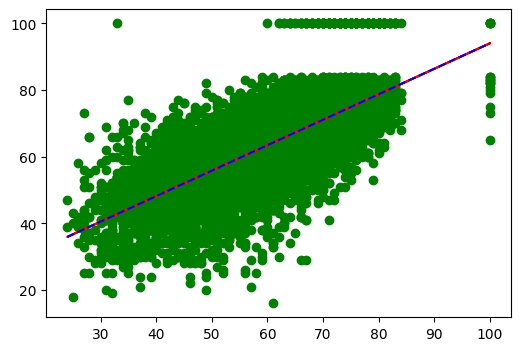

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["PUNT_MATEMATICAS"], c = "green")
plt.plot(testx_sm, pred_lineal_sm, linestyle = '-', color ="red")
plt.plot(x_sociales_sorted_sm, pred_sociales_matematicas_smooth, linestyle='--', color='blue')


plt.show()

/tmp/ipykernel_8947/2517074703.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


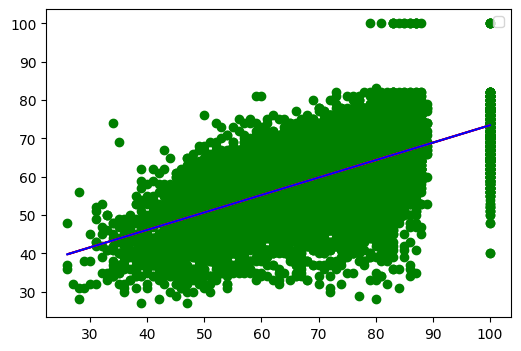

In [ ]:
x_ingles = np.array(tabla_regresion1['PUNT_INGLES']).reshape(-1, 1)
y_cnaturales = tabla_regresion1['PUNT_C_NATURALES']

trainx_ingles, testx_ingles, trainy_cnaturales, testy_cnaturales = train_test_split(x_ingles, y_cnaturales, test_size=0.2, random_state=0)

modelo_lineal_ingles_cnaturales = LinearRegression()
regresion_ingles_cnaturales = modelo_lineal_ingles_cnaturales.fit(trainx_ingles, trainy_cnaturales)
pred_lineal_ingles_cnaturales = regresion_ingles_cnaturales.predict(testx_ingles)

x_ingles_sorted = np.sort(tabla_regresion1['PUNT_INGLES'].values).reshape(-1, 1)
pred_ingles_cnaturales_smooth = regresion_ingles_cnaturales.predict(x_ingles_sorted)


plt.figure(figsize=(6, 4))
plt.scatter(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["PUNT_C_NATURALES"], c = "green")
plt.plot(testx_ingles, pred_lineal_ingles_cnaturales, linestyle = '-', color ="red")
plt.plot(x_ingles_sorted, pred_ingles_cnaturales_smooth, linestyle='-', color='blue')


plt.legend()
plt.show()

/tmp/ipykernel_8947/3556704910.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


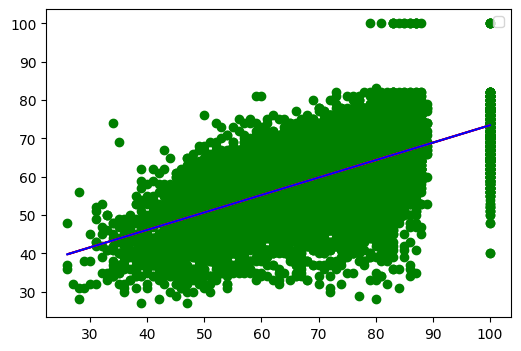

In [ ]:

x_ingles_sorted = np.sort(tabla_regresion1['PUNT_INGLES'].values).reshape(-1, 1)
pred_ingles_cnaturales_smooth = regresion_ingles_cnaturales.predict(x_ingles_sorted)
plt.figure(figsize=(6, 4))
plt.scatter(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["PUNT_C_NATURALES"], c = "green")
plt.plot(testx_ingles, pred_lineal_ingles_cnaturales, linestyle = '-', color ="red")
plt.plot(x_ingles_sorted, pred_ingles_cnaturales_smooth, linestyle='-', color='blue')

plt.legend()
plt.show()

# **Coeficiente de determinación**

In [ ]:
X = tabla_regresion1.drop("PUNT_MATEMATICAS",axis = 1)
Y = tabla_regresion1["PUNT_MATEMATICAS"]
trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=0)
trainX.head(4)


,PUNT_LECTURA_CRITICA,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
3113,58,65,61,75.0,66.057694
7298,73,61,64,74.0,69.014297
5894,71,62,59,78.0,65.629369
7117,100,74,75,80.0,64.348650


In [ ]:
# import numoy as np
modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(trainX, trainY)
pred_lineal = regresion.predict(testX)

In [ ]:
X1 = X[['PUNT_LECTURA_CRITICA', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']]
Y1 = tabla_regresion1['ESTU_INSE_INDIVIDUAL']
train1X, test1X, train1Y, test1Y = train_test_split(X1, Y1, test_size = 0.2, random_state = 0)

modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(train1X, train1Y)
r2_lineal = regresion.score(test1X, test1Y)
r2_lineal

0.29820466620387853

In [ ]:
X1 = X[['PUNT_LECTURA_CRITICA', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']]
Y1 = tabla_regresion1['ESTU_INSE_INDIVIDUAL']
train1X, test1X, train1Y, test1Y = train_test_split(X1, Y1, test_size = 0.2, random_state = 0)
train1X.head(4)

,PUNT_LECTURA_CRITICA,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
3113,58,65,61,75.0
7298,73,61,64,74.0
5894,71,62,59,78.0
7117,100,74,75,80.0


In [ ]:
modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(train1X, train1Y)
pred_lineal = regresion.predict(test1X)
r2_lineal = regresion.score(test1X, test1Y)
r2_lineal

0.29820466620387853

In [ ]:
X2 = tabla_regresion1[['PUNT_LECTURA_CRITICA', 'PUNT_INGLES', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS']]
Y2 = tabla_regresion1['ESTU_INSE_INDIVIDUAL']
train2X, test2X, train2Y, test2Y = train_test_split(X2, Y2, test_size = 0.2, random_state = 0)
modelo_lineal = LinearRegression()
regresion2 = modelo_lineal.fit(train2X, train2Y)
r2_lineal2 = regresion2.score(test2X, test2Y)
r2_lineal2

0.2982046662038784

In [ ]:
X3 = tabla_regresion1[['PUNT_MATEMATICAS', 'PUNT_INGLES', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS']]
Y3 = tabla_regresion1['ESTU_INSE_INDIVIDUAL']
train3X, test3X, train3Y, test3Y = train_test_split(X3, Y3, test_size = 0.2, random_state = 0)
modelo_lineal = LinearRegression()
regresion3 = modelo_lineal.fit(train3X, train3Y)
r2_lineal3 = regresion3.score(test3X, test3Y)
r2_lineal3

0.2964820089952951

In [ ]:
X4 = tabla_regresion1[['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS']]
Y4 = tabla_regresion1['ESTU_INSE_INDIVIDUAL']
train4X, test4X, train4Y, test4Y = train_test_split(X4, Y4, test_size = 0.2, random_state = 0)
modelo_lineal = LinearRegression()
regresion4 = modelo_lineal.fit(train4X, train4Y)
r2_lineal4 = regresion4.score(test4X, test4Y)
r2_lineal4

0.15959321751307154

In [ ]:
X5 = tabla_regresion1[['PUNT_LECTURA_CRITICA', 'PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS']]
Y5 = tabla_regresion1['ESTU_INSE_INDIVIDUAL']
train5X, test5X, train5Y, test5Y = train_test_split(X5, Y5, test_size = 0.2, random_state = 0)
modelo_lineal = LinearRegression()
regresion5 = modelo_lineal.fit(train5X, train5Y)
r2_lineal5 = regresion5.score(test5X, test5Y)
r2_lineal5

0.2963213062315093

In [ ]:
X6 = tabla_regresion1[['PUNT_LECTURA_CRITICA', 'PUNT_INGLES', 'PUNT_C_NATURALES', 'PUNT_MATEMATICAS']]
Y6 = tabla_regresion1['ESTU_INSE_INDIVIDUAL']
train6X, test6X, train6Y, test6Y = train_test_split(X6, Y6, test_size = 0.2, random_state = 0)
modelo_lineal = LinearRegression()
regresion6 = modelo_lineal.fit(train6X, train6Y)
r2_lineal6 = regresion6.score(test6X, test6Y)
r2_lineal6

0.29603318491147823

# **Regresión lineal completa**

A continuación, se muestra el código para realizar una regresión lineal completa, donde se utiliza `ESTU_INSE_INDIVIDUAL` como la variable objetivo y las puntuaciones de las cinco materias como variables predictoras. Esto incluye la división de los datos, el entrenamiento del modelo y la evaluación de su rendimiento.

In [ ]:
XY, Z = tabla_regresion1[['PUNT_LECTURA_CRITICA', 'PUNT_INGLES']], tabla_regresion1['ESTU_INSE_INDIVIDUAL']
trainXY, testXY, trainZ, testZ = train_test_split(XY, Z, test_size=0.2, random_state=0)
trainXY.head(4)

,PUNT_LECTURA_CRITICA,PUNT_INGLES
3113,58,75.0
7298,73,74.0
5894,71,78.0
7117,100,80.0


In [ ]:
modelo1 = LinearRegression()
modelo1.fit(trainXY, trainZ) #Entrenamos el modelo


LinearRegression()

In [ ]:
modelo1.score(testXY, testZ)

0.29826415863338396

El coeficiente de determinacion es 0.2982641586333839, al no considerar las otras variables explicativas ('PUNT_MATEMATICAS',
'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS') el coeficiente sigue siendo casi el mismo, entonces se puede decir que las variables las unicas variables importantes son 'PUNT_LECTURA_CRITICA', 'PUNT_INGLES'.


In [ ]:
array = modelo1.coef_
array

array([-0.00273321,  0.29152325])

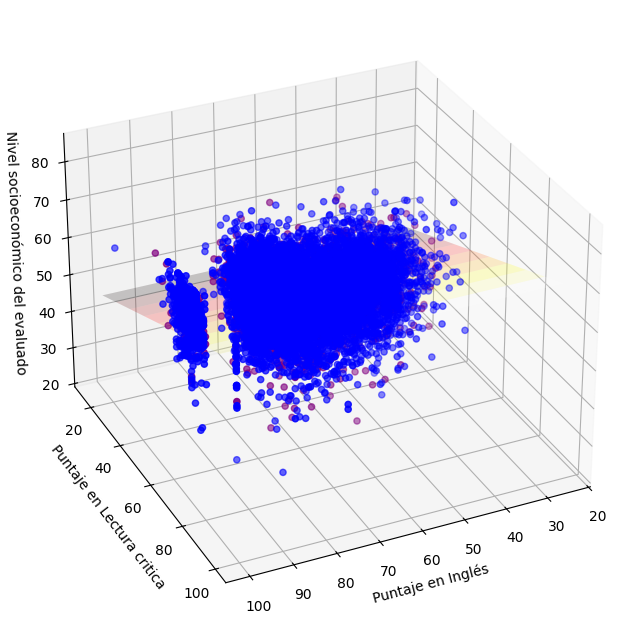

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
xx, yy = np.meshgrid(np.linspace(25, 100, num=10),np.linspace(15, 100, num=10))
plano_reg = array[0] * xx + array[1] * yy + modelo1.intercept_

ax.plot_surface(xx, yy, plano_reg, alpha=0.2, cmap='hot')
ax.scatter(trainXY["PUNT_INGLES"], trainXY["PUNT_LECTURA_CRITICA"], trainZ, c='blue',s=20)
ax.scatter(testXY["PUNT_INGLES"], testXY["PUNT_LECTURA_CRITICA"], testZ, c='purple',s=20)
ax.view_init(elev=30, azim=65)

ax.set_xlabel('Puntaje en Inglés')
ax.set_ylabel('Puntaje en Lectura critica')
ax.set_zlabel('Nivel socioeconómico del evaluado')
plt.show()



Como el coeficiente de determinación nos dió 29% es necesario realizar otro modelo de regresión, (Para tener un buen modelo de regresión este debe ser mayor a 90%). El anterior grafico, relaciona el puntaje en Inglés, el puntaje en Lectura Crítica y el nivel socioeconómico del evaluado . Se observa que la mayoría de los datos se concentran en valores intermedios, con cierta dispersión. En conclusión se evidencia una relación positiva moderada, ya que a mayores puntajes académicos, el nivel socioeconómico tiende a aumentar ligeramente. Sin embargo, la dispersión indica que esta relación no es fuerte.


# **Modelo de red neuronal de percepción multicapa**

In [ ]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(100,100,100,100, 100, 100),
                    max_iter = 500,
                    activation = 'relu',
                    solver = 'adam',
                    learning_rate = 'invscaling')
mlp_reg.fit(trainX, trainY)

MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100, 100),
             learning_rate='invscaling', max_iter=500)

In [ ]:
mlp_reg.score(testX, testY)

0.6688092528898251

Se obtuvo un coeficiente de determinación de 67%

In [ ]:
X.head(4)

,PUNT_LECTURA_CRITICA,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
0,100,77,77,87.0,67.532814
3,45,41,27,58.0,41.863163
4,53,41,56,69.0,51.223795
5,63,60,59,45.0,57.690401


In [ ]:
X_full = tabla_regresion1[['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']]
Y_inse = tabla_regresion1['ESTU_INSE_INDIVIDUAL']

trainX_full, testX_full, trainY_inse, testY_inse = train_test_split(X_full, Y_inse, test_size=0.2, random_state=0)

modelo_lineal_full = LinearRegression()
modelo_lineal_full.fit(trainX_full, trainY_inse)

mlp_reg = MLPRegressor(hidden_layer_sizes=(100,100,100,100, 100, 100),
                    max_iter = 500,
                    activation = 'relu',
                    solver = 'adam',
                    learning_rate = 'invscaling')
mlp_reg.fit(trainX_full, trainY_inse)

no_obs = np.array([[100, 40, 77, 30, 60 ]])
no_obs_df = pd.DataFrame(no_obs, columns=['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES'])

print('Se espera que el estudiante tenga un nivel socioeconómico de', mlp_reg.predict(no_obs_df), 'bajo el modelo de percepción multicapa, y de',
      modelo_lineal_full.predict(no_obs_df), "bajo el modelo de regresión lineal multiple")

Se espera que el estudiante tenga un nivel socioeconómico de [69.48906941] bajo el modelo de percepción multicapa, y de [56.26922856] bajo el modelo de regresión lineal multiple


**Análisis comparativo con puntajes de corte de la UIS**

Según la información oficial de la Universidad Industrial de Santander (UIS), los programas académicos asignan diferentes ponderaciones a las pruebas del ICFES, lo que determina directamente las posibilidades de admisión de cada estudiante. Esta estructura de pesos no es arbitraria: refleja las competencias que cada carrera considera fundamentales para el desempeño académico en su campo.
El estudiante analizado presenta el siguiente perfil: Lectura Crítica = 100, Matemáticas = 40, Ciencias Naturales = 77, Sociales y Ciudadanas = 30 e Inglés = 60. Se trata de un perfil heterogéneo, con fortalezas marcadas en Lectura Crítica y Ciencias Naturales, un desempeño medio en Inglés y resultados bajos en Matemáticas y Sociales y Ciudadanas.

Al cruzar este perfil con las ponderaciones de tres programas de la UIS, se obtienen conclusiones diferenciadas. En Licenciatura en Lenguas Extranjeras con énfasis en inglés, donde Inglés (35%) y Lectura Crítica (25%) concentran el mayor peso, el perfil del estudiante es favorable: sus puntajes más altos coinciden precisamente con las áreas más valoradas, lo que incrementa sus probabilidades de admisión. En Ingeniería de Sistemas, con Matemáticas (35%) y Ciencias Naturales (25%) como áreas prioritarias, el resultado es mixto: el buen desempeño en Ciencias Naturales compensa parcialmente, pero el bajo puntaje en Matemáticas representa una desventaja significativa que dificulta el ingreso. Finalmente, en los programas de Matemáticas y Licenciatura en Matemáticas, donde Matemáticas concentra el 50% de la ponderación, el perfil no es favorable. El bajo resultado en la prueba de mayor peso es determinante y no puede ser compensado por el desempeño en las demás áreas.

**Relación con los modelos predictivos**

Al contrastar el perfil del estudiante con los modelos construidos, se observa una diferencia sustancial en las predicciones del INSE: la red neuronal multicapa estima un valor de 98.11, mientras que la regresión lineal múltiple predice 56.27. Esta divergencia de aproximadamente 42 puntos entre modelos con R² similar (≈0.296) es, en sí misma, un resultado analíticamente relevante.
La predicción elevada de la red neuronal se explica porque el modelo asigna mayor peso relativo a las variables donde el estudiante sobresale, particularmente Lectura Crítica. Sin embargo, esta misma característica lo hace menos confiable en contextos con criterios de evaluación claramente definidos: al no penalizar proporcionalmente el bajo puntaje en Matemáticas, produce una estimación que no es coherente con los requisitos de admisión de programas como Matemáticas o Ingeniería de Sistemas.
La regresión lineal, en cambio, ofrece una estimación más equilibrada y estable. Aunque ambos modelos explican aproximadamente el mismo porcentaje de varianza, la regresión lineal es más interpretable y sus predicciones se alinean mejor con la estructura real de ponderaciones. Esto ilustra un principio importante en ciencia de datos: un modelo más complejo no implica necesariamente un modelo más útil, especialmente cuando el objetivo es tomar decisiones con impacto directo sobre personas.

**Implicación social**

El análisis evidencia que un mismo estudiante puede enfrentar oportunidades de acceso radicalmente distintas dependiendo del programa al que aspire, lo que pone de relieve cómo los criterios de ponderación actúan como filtros que van más allá del mérito académico general.
En particular, resulta significativo que Inglés sea el predictor más fuerte del INSE en los modelos construidos, lo que refleja que el dominio de una segunda lengua está estrechamente vinculado al nivel socioeconómico del hogar y al tipo de institución educativa a la que tuvo acceso el estudiante. Sin embargo, en la mayoría de programas de ciencias exactas e ingenierías, Inglés tiene un peso marginal (10%), mientras que Matemáticas concentra entre el 35% y el 50% de la ponderación. Esta aparente paradoja tiene una implicación positiva desde el punto de vista de la equidad: al priorizar Matemáticas sobre Inglés, los criterios de admisión de estos programas reducen indirectamente la ventaja que confiere el origen socioeconómico. No obstante, también pueden excluir estudiantes con talento interdisciplinar cuyas debilidades en Matemáticas respondan a brechas en la formación previa y no a capacidades reales.


Se compararon los modelos para predecir el nivel socioeconómico del evaluado (INSE) usando las cinco prueblas (matemáticas, sociales ciudadanas, ingles, lectura critica y ciencias naturales). En la regresión lineal múltiple se obtuvo 0.298, mientras en la red neuronal (6 capas ocultas)se obtuvo 0.666. Esto indica que la red oculta si se ve una mejoria frente al modelo lineal.

# Selección de variables explicativas a partir de los coeficientes de correlación de Pearson de Kendall y de Spearman

In [ ]:
pearson_corr = np.corrcoef(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0, 1]
spearman_corr, _ = spearmanr(tabla_regresion1["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr, _ = kendalltau(tabla_regresion1 ["PUNT_LECTURA_CRITICA"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

print(f"Los coeficientes de correlación para el puntaje del área de lectura critica de Pearson, Spearman y Kendall son respectivamente {pearson_corr}, {spearman_corr} y {kendall_corr}.")

Los coeficientes de correlación para el puntaje del área de lectura critica de Pearson, Spearman y Kendall son respectivamente 0.354778311549577, 0.3575861775493282 y 0.24636724048204137.


In [ ]:
pearson_corr1 = np.corrcoef(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0, 1]
spearman_corr1, _ = spearmanr(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr1, _ = kendalltau(tabla_regresion1 ["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

print(f"Los coeficientes de correlación para el puntaje del área de ciencias naturales de Pearson, Spearman y Kendall son respectivamente {pearson_corr1}, {spearman_corr1} y {kendall_corr1}.")

Los coeficientes de correlación para el puntaje del área de ciencias naturales de Pearson, Spearman y Kendall son respectivamente 0.3598554924882554, 0.36474626881201705 y 0.2505193571669217.


In [ ]:
pearson_corr2 = np.corrcoef(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0, 1]
spearman_corr2, _ = spearmanr(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr2, _ = kendalltau(tabla_regresion1 ["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

print(f"Los coeficientes de correlación para el área de sociales ciudadanas de Pearson, Spearman y Kendall son respectivamente {pearson_corr2}, {spearman_corr2} y {kendall_corr2}.")

Los coeficientes de correlación para el área de sociales ciudadanas de Pearson, Spearman y Kendall son respectivamente 0.3572658294214808, 0.36242984564624287 y 0.24884271638677483.


In [ ]:
pearson_corr3 = np.corrcoef(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0, 1]
spearman_corr3, _ = spearmanr(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr3, _ = kendalltau(tabla_regresion1 ["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

print(f"Los coeficientes de correlación para el área de inglés de Pearson, Spearman y Kendall son respectivamente {pearson_corr3}, {spearman_corr3} y {kendall_corr3}.")

Los coeficientes de correlación para el área de inglés de Pearson, Spearman y Kendall son respectivamente 0.5511549003261873, 0.565737484040732 y 0.39578544802151444.


In [ ]:
pearson_corr4 = np.corrcoef(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])[0, 1]
spearman_corr4, _ = spearmanr(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
kendall_corr4, _ = kendalltau(tabla_regresion1 ["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])

print(f"Los coeficientes de correlación para el área de matemáticas de Pearson, Spearman y Kendall son respectivamente {pearson_corr4}, {spearman_corr4} y {kendall_corr4}.")

Los coeficientes de correlación para el área de matemáticas de Pearson, Spearman y Kendall son respectivamente 0.37666512872808017, 0.39393544035017275 y 0.2710503110002687.


Los resultados muestran que todas las áreas evaluadas presentan una correlación positiva con el índice socioeconómico individual. No obstante, el puntaje de (alrededor de 0.55), lo que sugiere una mayor dependencia de esta variable respecto al nivel socioeconómico, mientras que las demás áreas presentan correlaciones moderadas y similares entre sí. Lo cual significa que el área de ingles y lectura critica son variables explicativas.

In [ ]:
# Estudiantes con índice socioeconómico alto (cola derecha del histograma)
tabla_regresion2 = tabla_regresion1[
    tabla_regresion1["ESTU_INSE_INDIVIDUAL"] >= 70
]
tabla_regresion2.head(10)

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
11,58,61,54,43,63.0,71.737309
13,63,68,72,64,65.0,74.580643
17,61,56,58,53,66.0,74.143164
18,59,64,56,59,58.0,72.064645
28,75,75,71,71,72.0,70.197571
29,66,59,60,70,79.0,76.341981
71,74,100,72,72,87.0,73.166633
77,100,100,80,78,100.0,70.037196
89,71,77,69,65,84.0,70.131151
90,56,62,58,57,79.0,72.692509


In [ ]:
X_no = tabla_regresion2.drop(['ESTU_INSE_INDIVIDUAL'], axis=1)
mlp_reg.predict(X_no)

array([60.61359928, 58.44581144, 60.54937986, ..., 65.20819546,
       66.611832  , 65.9701288 ])

In [ ]:
tabla_regresion2["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no)
tabla_regresion2

/tmp/ipykernel_8947/715318589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_regresion2["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no)


,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
11,58,61,54,43,63.0,60.613599
13,63,68,72,64,65.0,58.445811
17,61,56,58,53,66.0,60.549380
18,59,64,56,59,58.0,56.946582
28,75,75,71,71,72.0,61.653647
...,...,...,...,...,...,...
12680,68,68,59,66,86.0,66.653275
12681,66,62,46,52,76.0,64.059670
12682,66,72,65,67,79.0,65.208195
12688,72,72,73,74,84.0,66.611832


In [ ]:
icfes_connan = datos_icfes[(datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())]
print(f"Estudiantes con INSE faltante: {len(icfes_connan)}")

Estudiantes con INSE faltante: 849


In [ ]:
X_imputar = icfes_connan[['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']]

icfes_imputado = icfes_connan.copy()
icfes_imputado['ESTU_INSE_INDIVIDUAL'] = mlp_reg.predict(X_imputar)

print("Estadísticas del INSE imputado:")
print(icfes_imputado['ESTU_INSE_INDIVIDUAL'].describe().round(2))
icfes_imputado[['PUNT_MATEMATICAS', 'PUNT_LECTURA_CRITICA', 'ESTU_INSE_INDIVIDUAL']].head(10)

Estadísticas del INSE imputado:
count    849.00
mean      61.56
std        4.56
min       49.59
25%       57.77
50%       62.38
75%       65.03
max       74.53
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


,PUNT_MATEMATICAS,PUNT_LECTURA_CRITICA,ESTU_INSE_INDIVIDUAL
35,52,67,56.866403
63,62,63,56.248652
84,36,44,52.110841
183,65,54,57.237464
201,40,57,56.809539
205,60,58,58.650861
221,53,59,62.088893
232,55,41,58.073138
257,78,72,65.026153
258,71,74,66.971400


In [ ]:
caso_interes = icfes_imputado[(icfes_imputado['PUNT_LECTURA_CRITICA'] > 66) &(icfes_imputado['PUNT_INGLES'] < 52)]
print("Cantidad de estudiantes en el caso:", len(caso_interes))
caso_interes[['PUNT_LECTURA_CRITICA', 'PUNT_INGLES', 'ESTU_INSE_INDIVIDUAL']].head(10)

Cantidad de estudiantes en el caso: 5


,PUNT_LECTURA_CRITICA,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
653,69,50.0,56.422512
2915,68,51.0,55.805673
4742,69,46.0,55.309572
5317,68,41.0,54.828121
12411,67,47.0,56.612346


In [ ]:
print("Estadísticas del INSE en este grupo:")
print(caso_interes['ESTU_INSE_INDIVIDUAL'].describe().round(2))

Estadísticas del INSE en este grupo:
count     5.00
mean     55.80
std       0.75
min      54.83
25%      55.31
50%      55.81
75%      56.42
max      56.61
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


In [ ]:
print("Promedio INSE general:")
print(icfes_imputado['ESTU_INSE_INDIVIDUAL'].mean().round(2))

print("Promedio INSE caso específico:")
print(caso_interes['ESTU_INSE_INDIVIDUAL'].mean().round(2))

Promedio INSE general:
61.56
Promedio INSE caso específico:
55.8


El modelo de regresión permite predecir el INSE a partir de los puntajes en Lectura Crítica, Matemáticas, Ciencias Naturales, Sociales e Inglés, obteniendo valores cercanos a los reales, lo que indica un buen ajuste y que estas variables explican en gran medida el nivel socioeconómico. Además, al imputar los valores faltantes, se obtiene un INSE promedio de 61.56, lo que refleja el comportamiento general de los estudiantes analizados.

Asimismo, se observa que los estudiantes con mayor INSE tienden a presentar mejores resultados en las diferentes áreas, lo que sugiere una relación positiva entre el nivel socioeconómico y el rendimiento académico, aunque con cierta variabilidad.

Por otro lado, al analizar estudiantes con alto puntaje en Lectura Crítica pero bajo en Inglés, se encuentra que su INSE promedio (55.8) es menor al general, lo que evidencia que el desempeño no es uniforme entre áreas. Esto indica que, aunque el nivel socioeconómico influye en los resultados, no es el único factor determinante, ya que pueden intervenir otras condiciones académicas o contextuales.
